
# Analysis of specific junction
## Redefine consensus paths based on sequence information
In this notebook we're veryfying that the chosen consensus paths make evolutionary sense by comparing sequences directly with each other, going one level deeper than looking at block information. We're analyzing whether all consensus paths are unique or whether some should be merged.

We are exemplary considering junction CIRMBUYJFK_f__CWCCKOQCWZ_r.

Findings for junction CIRMBUYJFK_f__CWCCKOQCWZ_r:
- Even though there are some mismatch columns in the alignment, those are usually point mutations found in one or maximally 2 sequences. These mutations could also stem from sequencing errors.
- Block 964531385716605116 (which is found in consensus path 1 only) has a lot of variation, however this stems from only one of the 13 isolates containing this blog
- for block 6932368721519041699 there are actually two different versions, it is a duplicated block, it is inserted at many different positions in the genome
- Core block 16494405553751752639 seems to have two versions, one version belongs to the short consensus path consensus_3, the other version belongs to the longer consensus path (1 and 2), the other core block 11400043001338627984 has the same two versions as well as all shared blocks
    - clustering isolates by core block similarity (e.g. first core block) shows perfect seperation between consensus_3 and consensus_1/2
    - wrongly forcing 3 clusters intermixes isolates between consensus_1 and consensus_2
    - we should have 2 consensus paths



In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import mplcursors

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import Counter

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree
from junction_analysis.junction_trees import build_trees_for_all_consensus
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_combined, plot_junction_pangraph_interactive, plot_dendrogram
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_isolate_sequence

In [11]:
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

consensus_paths, path_dict, dedup_block_freq, similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=5, rare_edge_threshold=5, min_n_isolates_per_consensus=5)

Found 3 unique paths.


In [12]:
summary_df = pd.read_csv(f"../results/block_alignments/{example_junction}/{example_junction}_alignment_stats.csv")
summary_df.sort_values('avg_pairwise_dist')

,file,block_id,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len,tree_built
0,block_185719230501067033_aln.fa,185719230501067033,4,4204,4204,0,0,1,0.000238,0.000000,0.000000,4,4,False,False,4204,True
37,block_16556873922195442803_aln.fa,16556873922195442803,2,1661,1661,0,0,0,0.000000,0.000000,0.000000,2,2,False,False,1661,False
33,block_16056383497489254679_aln.fa,16056383497489254679,170,193,142,43,8,0,0.000000,0.000000,0.000000,170,170,False,False,142,False
23,block_11445151531734952644_aln.fa,11445151531734952644,170,322,322,0,0,0,0.000000,0.000000,0.000000,170,170,False,False,322,False
18,block_9242629882957449119_aln.fa,9242629882957449119,168,812,812,0,0,0,0.000000,0.000000,0.000000,168,168,False,False,812,False
16,block_7844090243072536214_aln.fa,7844090243072536214,1,1446,1446,0,0,0,0.000000,0.000000,0.000000,1,1,False,False,1446,False
15,block_7754538651979209778_aln.fa,7754538651979209778,166,304,294,10,0,2,0.006803,0.000000,0.000000,166,166,False,False,294,False
40,block_18228278273347143766_aln.fa,18228278273347143766,1,820,820,0,0,0,0.000000,0.000000,0.000000,1,1,False,False,820,False
1,block_517157241956952768_aln.fa,517157241956952768,7,1253,1248,3,2,0,0.000000,0.000000,0.000000,7,7,False,False,1248,True
7,block_2278011600046483881_aln.fa,2278011600046483881,1,37622,37622,0,0,0,0.000000,0.000000,0.000000,1,1,False,False,37622,False


- One clearly observes that the shared blocks between all sequences have higher variability than the prophage insertion in consensus 1.
- There are two insertion sequences with highest variability that have been inserted multiple times in different versions
- Other insertion sequences are mostly less frequent and are nearly identical between copies

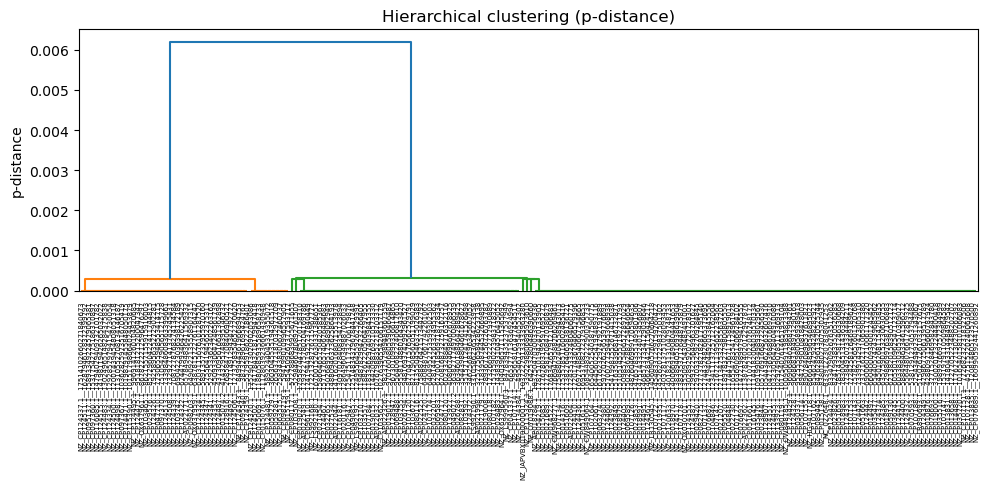

In [13]:
# TODO: find a better way to do this (cluster sequences, talk with Marco what would be best)

# get alignment from blog alignments with mafft
aln_path = f"../results/block_alignments/{example_junction}/block_11400043001338627984_aln.fa"
distance_matrix, Z, names = cluster_alignment(aln_path)

plot_dendrogram(Z, names)

In [14]:
clusters = retrieve_cluster_assignments(Z, names, n_clusters=3)

plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters,
    title = "Junction Block Structure with 3 CLusters"
)

In [15]:
clusters_2 = retrieve_cluster_assignments(Z, names, n_clusters=2)
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_2,
    title = "Junction Block Structure with 2 Clusters"
)

## Compare consensus paths
Pairwise comparison of variation in shared and non-shared blocks between consensus paths.

In [16]:
consensus_paths, path_dict, dedup_block_freq, similarity_matrix, assignment_df = find_consensus_paths(example_pangraph, rare_block_threshold=10, rare_edge_threshold=10, min_n_isolates_per_consensus=5)
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_2,
    title = "Junction Block Structure with 2 Clusters"
)

Found 2 unique paths.


In [10]:
consensus_path_1, consensus_path_2 = consensus_paths[0].nodes, consensus_paths[1].nodes

def calculate_shared_block_split(consensus_path_1, consensus_path_2):

    shared_blocks = [n.id for n in consensus_path_1 if n in consensus_path_2]
    cons_1_blocks = [n.id for n in consensus_path_1 if n not in consensus_path_2]
    cons_2_blocks = [n.id for n in consensus_path_2 if n not in consensus_path_1]

    return shared_blocks, cons_1_blocks, cons_2_blocks

shared_blocks, cons_1_blocks, cons_2_blocks = calculate_shared_block_split(consensus_path_1, consensus_path_2)

def weighted_mean(df, value_col):
    return np.average(df[value_col], weights=df["alignment_len"])

# Shared blocks
df_shared = summary_df[summary_df['block_id'].isin(shared_blocks)]
print("Weighted pairwise distance (shared): " +
      str(weighted_mean(df_shared, "avg_pairwise_dist")))
print("Weighted consensus distance (shared): " +
      str(weighted_mean(df_shared, "avg_consensus_dist")))

# Unique to consensus 1
df_cons1 = summary_df[summary_df['block_id'].isin(cons_1_blocks)]
print("Weighted pairwise distance (consensus 1 unique): " +
      str(weighted_mean(df_cons1, "avg_pairwise_dist")))
print("Weighted consensus distance (consensus 1 unique): " +
      str(weighted_mean(df_cons1, "avg_consensus_dist")))

# There are no blocks unique to consensus 2

Weighted pairwise distance (shared): 0.0019427680108800248
Weighted consensus distance (shared): 0.0012567338180540135
Weighted pairwise distance (consensus 1 unique): 5.878038426807059e-05
Weighted consensus distance (consensus 1 unique): 3.518823046031321e-05


(<Figure size 1200x4972 with 1 Axes>, <Axes: xlabel='genomic position (bp)'>)

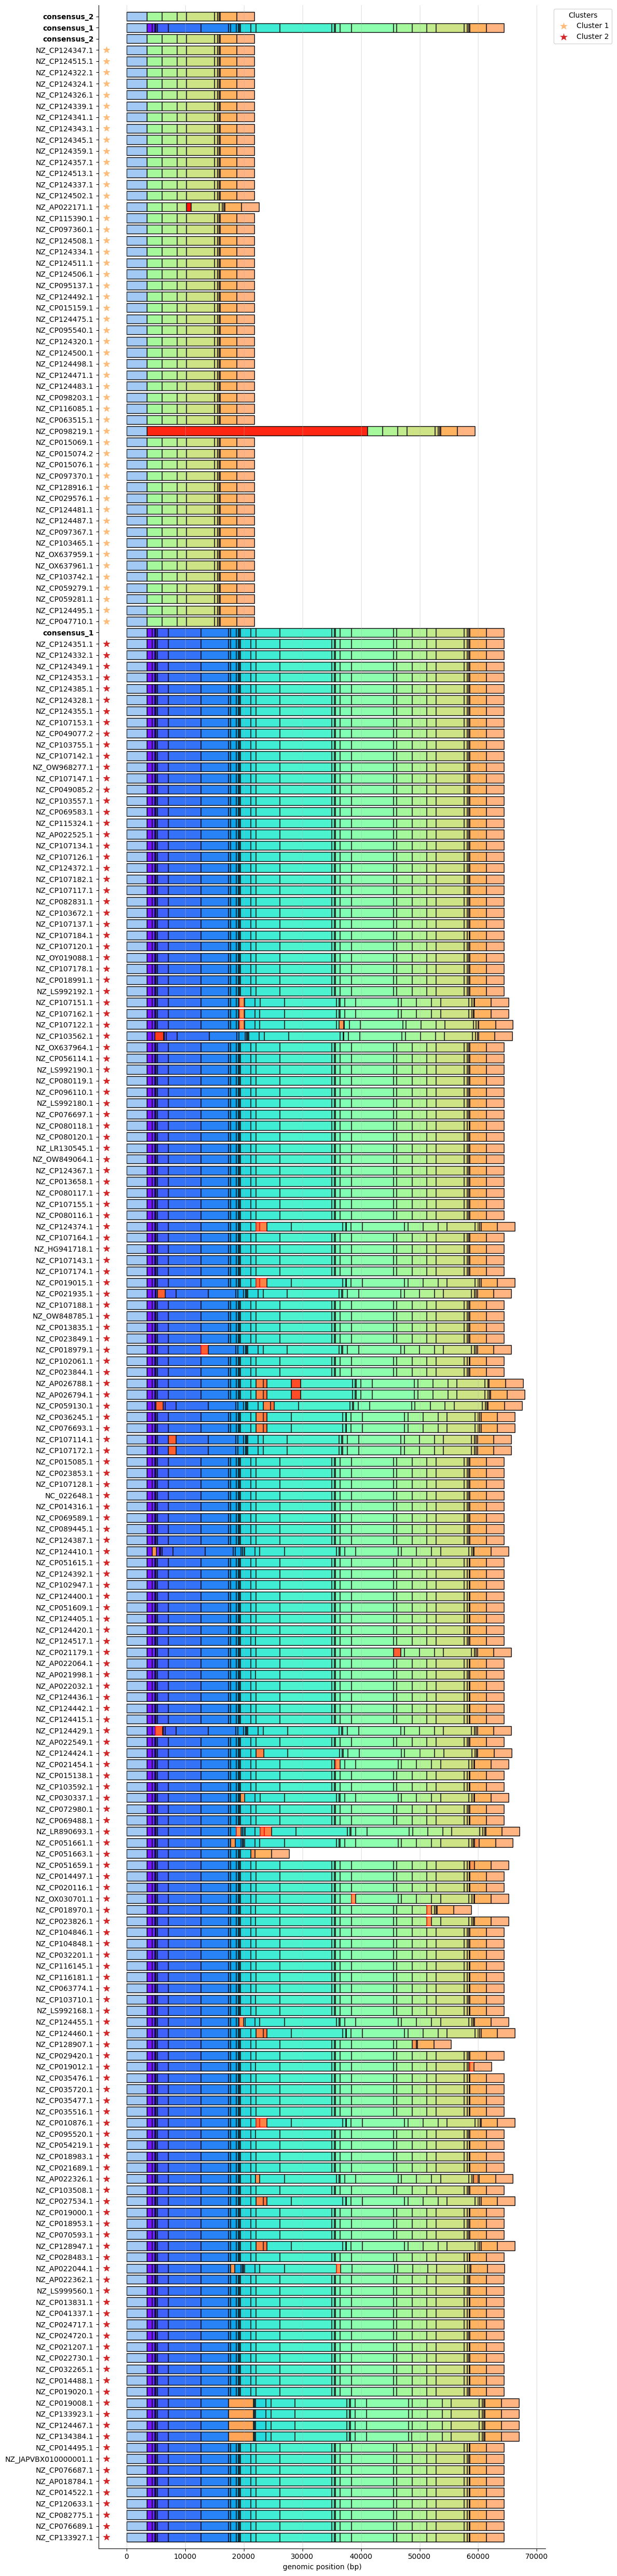

In [48]:
# not interactively plot junction
plot_junction_pangraph_combined(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_2,
)

## Consider trees
1. Use all blogs that are shared in at least threshold = 95% of isolates
2. Use all blogs that are shared in at least threshold = 95% of isolates in one consensus path

In [ ]:
from typing import Dict, List

def get_shared_nodes(consensus_paths: List[Path]):
    """
    Return all nodes shared between ALL consensus paths.
    - Sharedness is defined by node.id (ignores strand/context).
    - The result preserves the order of appearance in the first path.
    - Each shared id appears at most once in the output (first occurrence from path 0).
    """

    if not consensus_paths:
        return []

    # 1. Build set of ids for each path
    path_sets = []
    for path in consensus_paths:
        dedup_blocks_in_path = {node for node in path.nodes}
        path_sets.append(dedup_blocks_in_path)

    # 2. Intersection of ids across all paths
    shared_dedup_blocks = set.intersection(*path_sets)

    # 3. Preserve order of first path, pick first occurrence of each shared id
    shared_dedup_blocks_in_order = []

    for node in consensus_paths[0].nodes:
        if node in shared_dedup_blocks:
            shared_dedup_blocks_in_order.append(node)

    return shared_dedup_blocks_in_order


def isolates_with_all_shared_blocks(path_dict: Dict[str, pu.Path],
                                    shared_nodes: List[pu.DeduplicatedNode]) -> List[str]:
    """
    Return all isolate IDs whose path contains *all* shared blocks.
    """
    shared_ids = {node for node in shared_nodes}

    isolates = []
    for isolate, path in path_dict.items():
        # all block ids present in this isolate's path
        ids_in_path = {node for node in path.nodes}

        # check: does this isolate contain all shared block IDs?
        if shared_ids.issubset(ids_in_path):
            isolates.append(isolate)

    return isolates

def write_shared_nodes_fasta(pangraph, path_dict, shared_nodes, shared_node_isolates, output_path):

    shared_id_set = {node for node in shared_nodes}

    fasta_records = []
    for isolate in shared_node_isolates:
        seq = ""
        for block in path_dict[isolate].nodes:
            if block in shared_id_set:
                seq = seq + get_isolate_sequence(pangraph, block.id, block.nid)
        record = SeqRecord(Seq(seq), id = isolate, description = "")
        fasta_records.append(record)

    SeqIO.write(fasta_records, output_path, "fasta")



In [ ]:
# get blocks within 95% of isolates --> just use dedup block frequencies (one deduplicated block can only appear once per isolate)

# retrieve all blocks that are part of all consensus paths
shared_nodes = get_shared_nodes(consensus_paths)
# create fasta file that contains sequences that are contained in any of these consensus paths for alignment
# find all isolated that contain all of these blocks
shared_node_isolates = isolates_with_all_shared_blocks(path_dict, shared_nodes)
print(f"{len(shared_node_isolates)/len(path_dict)*100:.2f}% of isolates contain shared consensus blocks")

# create fasta file of block sequences
parent_dir = "../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r"
write_shared_nodes_fasta(example_pangraph, path_dict, shared_nodes, shared_node_isolates, f"{parent_dir}/all_consensus_shared_blocks.fa")

aln_file = f"{parent_dir}/all_consensus_shared_blocks_aln.fa"
        
# Run MAFFT quietly (you can remove '--quiet' if you want verbose output), 25s
subprocess.run(
    ["mafft", "--quiet", f"{parent_dir}/all_consensus_shared_blocks.fa"],
    stdout=open(aln_file, "w"),
    check=True
)

# Create tree
tree_file = f"{parent_dir}/all_consensus_shared_blocks_aln.tree"

# run FastTree, 12 s
# gaps are not considered as mismatches
subprocess.run(
    ["fasttree", "-nt", "-gtr", aln_file],   # -nt for nucleotide data
    stdout=open(tree_file, "w"),
    check=True
)



97.75% of isolates contain shared consensus blocks


FastTree Version 2.2.0 Double precision
Alignment: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/all_consensus_shared_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.17 seconds
Refining topology: 23 rounds ME-NNIs, 2 rounds ME-SPRs, 12 rounds ML-NNIs
      0.17 seconds: ME NNI round 1 of 23, 1 of 54 splits
      0.71 seconds: SPR round   1 of   2, 101 of 110 nodes
      1.29 seconds: SPR round   2 of   2, 101 of 110 nodes
Total branch-length 0.008 after 1.38 sec

WARNING! This alignment consists of closely-related and very-long sequences.
WARNING! FastTree (or other standard maximum-likelihood tools)
may not be appropriate for aligments of very closely-related sequences
like this one, as FastTree does not account for recombina

CompletedProcess(args=['fasttree', '-nt', '-gtr', '../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/all_consensus_shared_blocks_aln.fa'], returncode=0)

In [11]:
clusters_shared_blocks_n_clusters = cluster_by_tree(tree_file, n_clusters=3)
clusters_shared_blocks_seq_sim = cluster_by_tree(tree_file, distance_threshold = 0.001) # choose threshold that is age of the tree with average substitution rate (average substitutions within age of tree is approx. 0.0001)
clusters_shared_blocks_frac = cluster_by_tree(tree_file, frac_of_max=0.05)
cluster_map_genome_tree_n_clusters = cluster_by_tree("../config/polished_tree.nwk", n_clusters = 2)
cluster_map_genome_tree_seq_sim = cluster_by_tree("../config/polished_tree.nwk", distance_threshold=0.0001)
cluster_map_genome_tree_frac = cluster_by_tree("../config/polished_tree.nwk", frac_of_max=0.3)


Formed 3 clusters
Formed 2 clusters
Using distance threshold = 0.000280 (= 5.0% of max distance 0.005593)
Formed 2 clusters
Formed 2 clusters
Formed 3 clusters
Using distance threshold = 0.000048 (= 30.0% of max distance 0.000161)
Formed 16 clusters


In [12]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_shared_blocks_seq_sim,
)

In [13]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_shared_blocks_frac,
)

In [14]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=cluster_map_genome_tree_seq_sim,
)

In [15]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=cluster_map_genome_tree_frac,
)

<Figure size 1000x1200 with 0 Axes>

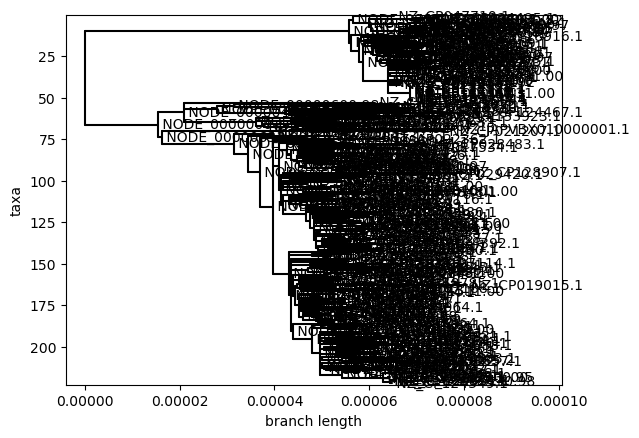

In [70]:
tree = Phylo.read("../config/polished_tree.nwk", "newick")

plt.figure(figsize=(10, 12))
Phylo.draw(tree) 

Repeat the same analysis within a consensus path.

In [ ]:
from collections import Counter
import math

def get_shared_nodes_per_consensus(consensus_paths, assignment_df, path_dict, frac=0.95):
    """
    For each consensus path, find nodes that are present in at least `frac`
    of its assigned isolates.

    Parameters
    ----------
    consensus_paths : list
        List of consensus path objects; each has a `.nodes` attribute.
    assignment_df : pd.DataFrame
        DataFrame with index = isolate names and column 'best_consensus'
        containing entries like 'consensus_1', 'consensus_2', ...
    path_dict : dict
        {isolate_name: path_object}, where each path_object has `.nodes`.
    frac : float
        Fraction of isolates that must contain a node to be kept (e.g. 0.95).

    Returns
    -------
    dict
        { 'consensus_1': [node_ids...],
          'consensus_2': [node_ids...],
          ... }
        Nodes are ordered as in the corresponding consensus path.
    """
    consensus_shared_nodes = {}
    consensus_isolates_with_all_shared = {}

    for idx, con_path in enumerate(consensus_paths):
        consensus_label = f"consensus_{idx+1}"

        # all isolates assigned to this consensus
        consensus_isolates = assignment_df[
            assignment_df['best_consensus'] == consensus_label
        ].index

        n_iso = len(consensus_isolates)
        if n_iso == 0:
            consensus_shared_nodes[consensus_label] = []
            continue

        # count in how many isolate paths each node appears
        node_counts = Counter()
        for iso in consensus_isolates:
            iso_path = path_dict[iso]
            # count each block at most once per isolate
            for node in set(iso_path.nodes):
                node_counts[node] += 1

        # threshold: at least frac of isolates
        threshold = math.ceil(frac * n_iso)

        # nodes that are in >= frac of isolates
        shared_nodes = [node for node, c in node_counts.items() if c >= threshold]

        # check for nodes not in the consensus path
        off_consensus = [n for n in shared_nodes if n not in con_path.nodes]
        if off_consensus:
            print(
                f"⚠️ Warning: {len(off_consensus)} shared nodes for {consensus_label} "
                f"are NOT part of the consensus path: {off_consensus}"
            )

        # optionally, order them as in the consensus path
        order = {node: i for i, node in enumerate(con_path.nodes)}
        shared_nodes_sorted = sorted(shared_nodes, key=lambda x: order.get(x, 10**9))

        consensus_shared_nodes[consensus_label] = shared_nodes_sorted

        shared_ids = set(shared_nodes_sorted)

        isolates_with_all = []
        # Note: if shared_ids is empty, set().issubset(...) is True for all isolates
        for iso in consensus_isolates:
            ids_in_path = set(path_dict[iso].nodes)
            if shared_ids.issubset(ids_in_path):
                isolates_with_all.append(iso)

        consensus_isolates_with_all_shared[consensus_label] = isolates_with_all

    return consensus_shared_nodes, consensus_isolates_with_all_shared




In [32]:
# get blocks that are shared between 95% of paths below a consensus path
consensus_shared_nodes, consensus_isolates_with_all_shared = get_shared_nodes_per_consensus(consensus_paths, assignment_df, path_dict)

# create fasta file of block sequences, takes up to 20 min
parent_dir = "../results/marie_playground/consensus_tree"
build_trees_for_all_consensus(consensus_paths, consensus_shared_nodes, consensus_isolates_with_all_shared, example_pangraph, path_dict, parent_dir)

consensus_1
Wrote FASTA: ../results/marie_playground/consensus_tree/consensus_1_shared_blocks.fa
Wrote alignment: ../results/marie_playground/consensus_tree/consensus_1_shared_blocks_aln.fa


FastTree Version 2.2.0 Double precision
Alignment: ../results/marie_playground/consensus_tree/consensus_1_shared_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
      0.70 seconds: Top hits for    104 of    106 seqs (at seed    100)
      2.01 seconds: Joined    100 of    103
Initial topology in 2.04 seconds
Refining topology: 27 rounds ME-NNIs, 2 rounds ME-SPRs, 13 rounds ML-NNIs
      2.24 seconds: ME NNI round 1 of 27, 101 of 104 splits, 30 changes (max delta 0.000)
      2.46 seconds: ME NNI round 2 of 27, 101 of 104 splits, 9 changes (max delta 0.000)
      2.68 seconds: ME NNI round 3 of 27, 101 of 104 splits, 3 changes (max delta 0.000)
      2.88 seconds: ME NNI round 4 of 27, 101 of 104 splits, 2 changes (max delta 0.000)
      3.08 seconds: ME NNI r

Wrote tree: ../results/marie_playground/consensus_tree/consensus_1_shared_blocks_aln.newick
consensus_2
Wrote FASTA: ../results/marie_playground/consensus_tree/consensus_2_shared_blocks.fa
Wrote alignment: ../results/marie_playground/consensus_tree/consensus_2_shared_blocks_aln.fa


FastTree Version 2.2.0 Double precision
Alignment: ../results/marie_playground/consensus_tree/consensus_2_shared_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.02 seconds
Refining topology: 13 rounds ME-NNIs, 2 rounds ME-SPRs, 7 rounds ML-NNIs
      0.13 seconds: ME NNI round 9 of 13, 1 of 8 splits
Total branch-length 0.000 after 0.15 sec

WARNING! This alignment consists of closely-related and very-long sequences.
WARNING! FastTree (or other standard maximum-likelihood tools)
may not be appropriate for aligments of very closely-related sequences
like this one, as FastTree does not account for recombination or gene conversion

ML-NNI round 1: LogLk = -30274.545 NNIs 3 max delta 0.00 Time 0.26
      0.26 seconds: Optimizing GTR model, st

Wrote tree: ../results/marie_playground/consensus_tree/consensus_2_shared_blocks_aln.newick
Done building trees for all consensus paths.


Total time: 1.93 seconds Unique: 10/52 Bad splits: 0/7


In [ ]:
# get blocks that are shared between 95% of paths below a consensus path
consensus_shared_nodes, consensus_isolates_with_all_shared = get_shared_nodes_per_consensus(consensus_paths, assignment_df, path_dict)

# create fasta file of block sequences, takes up to 20 min
parent_dir = "../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r"
build_trees_for_all_consensus(consensus_paths, consensus_shared_nodes, consensus_isolates_with_all_shared, example_pangraph, path_dict, parent_dir)

[consensus_1] Wrote FASTA: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_1_shared_blocks.fa


python(93076) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[consensus_1] Wrote alignment: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_1_shared_blocks_aln.fa


python(93516) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
FastTree Version 2.2.0 Double precision
Alignment: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_1_shared_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
      0.76 seconds: Top hits for    104 of    106 seqs (at seed    100)
      1.59 seconds: Joined    100 of    103
Initial topology in 1.60 seconds
Refining topology: 27 rounds ME-NNIs, 2 rounds ME-SPRs, 13 rounds ML-NNIs
      1.72 seconds: ME NNI round 1 of 27, 101 of 104 splits, 30 changes (max delta 0.000)
      1.84 seconds: ME NNI round 2 of 27, 101 of 104 splits, 9 changes (max delta 0.000)
      1.95 seconds: ME NNI round 3 of 27, 101 of 104 splits, 3 changes (max delta 0.000)
     

[consensus_1] Wrote tree: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_1_shared_blocks_aln.newick
[consensus_2] Wrote FASTA: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_2_shared_blocks.fa


python(93555) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[consensus_2] Wrote alignment: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_2_shared_blocks_aln.fa


python(93664) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
FastTree Version 2.2.0 Double precision
Alignment: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_2_shared_blocks_aln.fa
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
Initial topology in 0.01 seconds
Refining topology: 13 rounds ME-NNIs, 2 rounds ME-SPRs, 7 rounds ML-NNIs
      0.11 seconds: ME NNI round 9 of 13, 1 of 8 splits
Total branch-length 0.000 after 0.12 sec

WARNING! This alignment consists of closely-related and very-long sequences.
WARNING! FastTree (or other standard maximum-likelihood tools)
may not be appropriate for aligments of very closely-related sequences
like this one, as FastTree does not account for recombination or gene conversion


[consensus_2] Wrote tree: ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_2_shared_blocks_aln.newick
Done building trees for all consensus paths.


Total time: 1.44 seconds Unique: 10/52 Bad splits: 0/7


In [17]:
clusters_consensus_1 = cluster_by_tree("../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_1_shared_blocks_aln.newick", distance_threshold=0.0001)
clusters_consensus_2 = cluster_by_tree("../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r/consensus_2_shared_blocks_aln.newick", distance_threshold=0.0001)
#clusters_shared_blocks_seq_sim = cluster_by_tree(tree_file, distance_threshold = 0.001) # choose threshold that is age of the tree with average substitution rate (average substitutions within age of tree is approx. 0.0001)
#clusters_shared_blocks_frac = cluster_by_tree(tree_file, frac_of_max=0.05)

Formed 5 clusters
Formed 3 clusters


In [18]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_consensus_1,
)

In [19]:
plot_junction_pangraph_interactive(
    example_pangraph,
    show_consensus=True,
    consensus_paths=consensus_paths,
    assignments=assignment_df,
    order="tree",
    cluster_map=clusters_consensus_2,
)